### 🔹 Задача Супер ЭТО ДОМАШКА
Построить лучшую логистическую регрессию на датасете Титаник


В гугл драйве будет датасет



Вам нужны будут только train.csv and test.csv


train.csv ---> Для тренировки вашей модели


test.csv ---> Для проверки вашей модели


Никаких Cross Validation; Потому что датасет и так уже идеально разделен чтобы трейн был отличным для тренировки модели а тест нужен для тренировки гиперпараметров но мы будем брать тест как для проверки наших моделей

In [1]:
# Почистить датасет
# Очистить дубликаты
# Пропуски
# Проверка Outliers
# распределние данных --> log(x), exp(x)
# Энкодинг Категориальных данных
# Убрать фичи с корреляцией
# Feature Engineering
# Scaler
# "print(0)" -- acc(98%)  SMOTE, Undersampling, Oversampling, Class Weights,
# Model == LogisticRegression()  --1000  penalty == "l1" GOOGLE
# Feature Importance, Logistic Regression
# Model = LogisticRegression() --200
# Metrics: Cross Entropy


## Ипорт библиотек

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

## Загрузка данных

In [2]:
#Разделяем train и test, выводим head
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

#Чтобы не делать лишнюю строчку, для вывода test.head() делаем через display
train_head = train.head().copy()
train_head['dataset'] = 'train'

test_head = test.head().copy()
test_head['dataset'] = 'test'

display(pd.concat([train_head, test_head], ignore_index = True))

#Тут выводятся первые 5 записей train и test, как видим начиная с 5 у нас Survived NaN, т.к. этого параметра в test нету

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,dataset
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,train
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,train
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,train
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,train
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,train
5,892,NaN,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,test
6,893,NaN,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,test
7,894,NaN,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,test
8,895,NaN,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,test
9,896,NaN,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,test


In [4]:
#Проверим на дубликаты
print("Дубли в Train:", train.duplicated().sum())
train = train.drop_duplicates()
print("Дубли в Test:", test.duplicated().sum())
test = test.drop_duplicates()

Дубли в Train: 0
Дубли в Test: 0


In [5]:
#Смотрим все числовые значения! Не выводит категориальные
train_desc = train.describe()
train_desc.columns = [F"train_{c}" for c in train_desc.columns]

test_desc = test.describe()
test_desc.columns = [F"test_{c}" for c in test_desc.columns]

desc_comparison = pd.concat([train_desc, test_desc], axis = 1)
display(desc_comparison)

#Для компакности использует такую же технику как ранее делали с head

,train_PassengerId,train_Survived,train_Pclass,train_Age,train_SibSp,train_Parch,train_Fare,test_PassengerId,test_Pclass,test_Age,test_SibSp,test_Parch,test_Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [6]:
#Далее смотрим пропуски
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

#По моему личному мнению вместо стандартного использования print в каждом по отдельности train и test, display делает это аккуратней
missing_comparison = pd.concat([missing_train, missing_test], axis=1)
missing_comparison.columns = ['train_missing', 'test_missing']

missing_comparison = missing_comparison.sort_values(by='train_missing', ascending=False)

display(missing_comparison)

,train_missing,test_missing
Cabin,687,327.0
Age,177,86.0
Embarked,2,0.0
PassengerId,0,0.0
Survived,0,NaN
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
SibSp,0,0.0
Parch,0,0.0


In [6]:
#Теперь посмотрим на info, чтобы понимать что является числовым, что является категориальным. Плюс выводим уникальные значения
train_info = pd.DataFrame({
    'train_dtype': train.dtypes,
    'train_unique': train.nunique()
})

test_info = pd.DataFrame({
    'test_dtype': test.dtypes,
    'test_unique': test.nunique()
})

info_comparison = pd.concat([train_info, test_info], axis=1)

info_comparison = info_comparison.sort_values(by='train_unique', ascending=False)

display(info_comparison)

,train_dtype,train_unique,test_dtype,test_unique
PassengerId,int64,891,int64,418.0
Name,object,891,object,418.0
Ticket,object,681,object,363.0
Fare,float64,248,float64,169.0
Cabin,object,147,object,76.0
Age,float64,88,float64,79.0
SibSp,int64,7,int64,7.0
Parch,int64,7,int64,8.0
Pclass,int64,3,int64,3.0
Embarked,object,3,object,3.0


In [9]:
# Смотрим кол-во выживших
train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

## Графики

<Axes: xlabel='Age', ylabel='Count'>

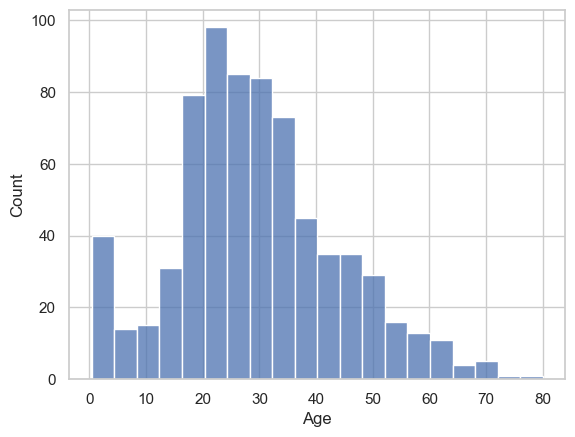

In [12]:
# Смотрим возраст
sns.histplot(train['Age'].dropna())

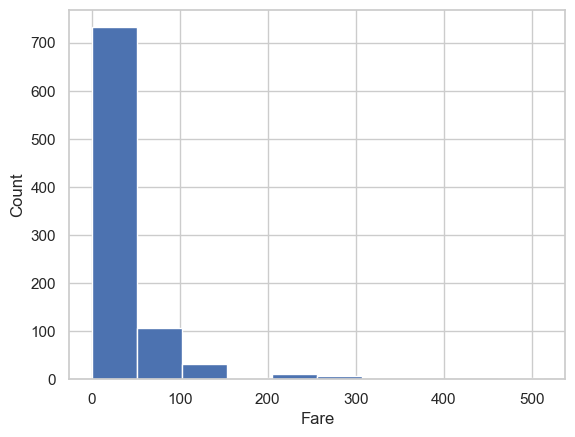

In [19]:
# Кол-во и стоимость билетов
plt.hist(train['Fare'], bins=10)
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()

Pclass  Sex     Survived
1       female  1           0.968085
                0           0.031915
        male    0           0.631148
                1           0.368852
2       female  1           0.921053
                0           0.078947
        male    0           0.842593
                1           0.157407
3       female  0           0.500000
                1           0.500000
        male    0           0.864553
                1           0.135447
Name: proportion, dtype: float64

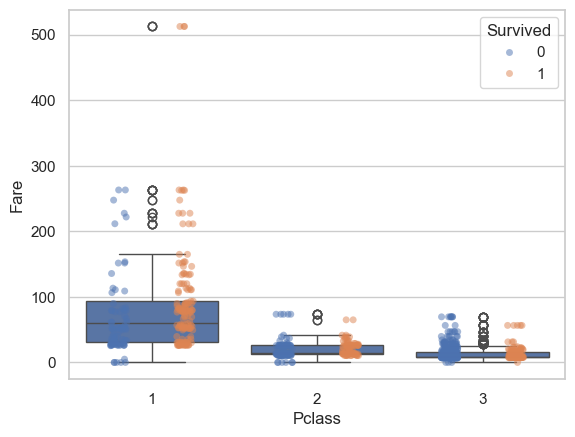

In [26]:
# Влияние класса билета на выживаемость
sns.boxplot(x='Pclass', y='Fare', data=train)
sns.stripplot(x='Pclass', y='Fare', data=train, hue='Survived',
              dodge=True, jitter=True, alpha=0.5)

train.groupby(['Pclass', 'Sex'])['Survived'].value_counts(normalize=True)

In [28]:
# Процент выживших в зависимости от класса
pd.crosstab(train['Pclass'], train['Survived'], normalize='index')

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


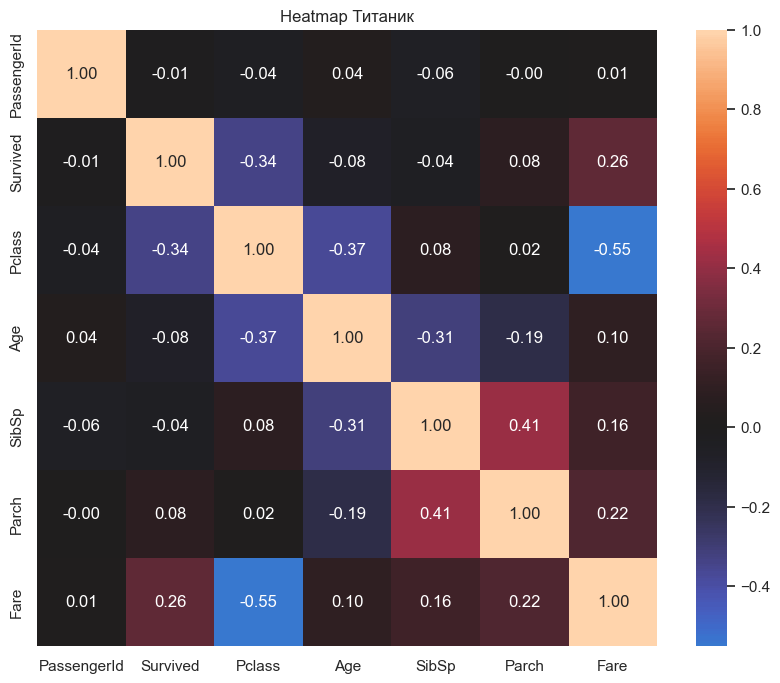

In [29]:
# Делаем Heatmap 
numeric_features = train.select_dtypes(include=[np.number])

corr_matrix = numeric_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,        
    fmt=".2f",    
    center=0
)

plt.title("Heatmap Титаник")
plt.show()

<Axes: xlabel='Embarked', ylabel='count'>

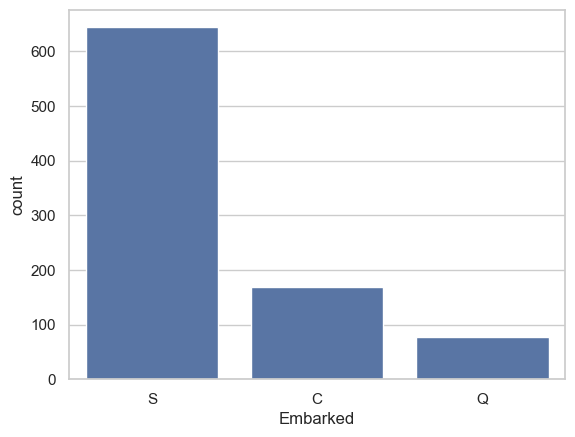

In [33]:
# Точки отправки
sns.countplot(x='Embarked', data=train)

<Axes: xlabel='SibSp', ylabel='count'>

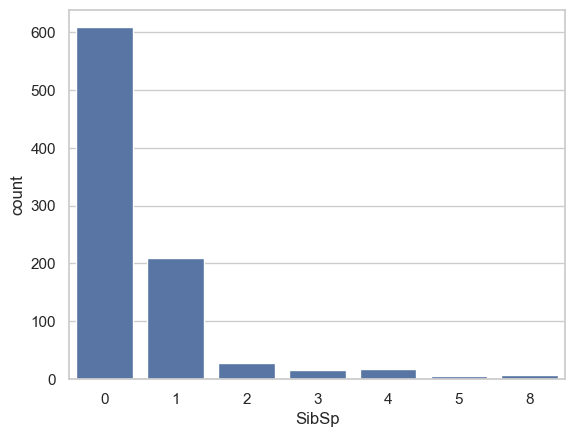

In [34]:
# Кол-во родственников
sns.countplot(x='SibSp', data=train)

<Axes: xlabel='Parch', ylabel='count'>

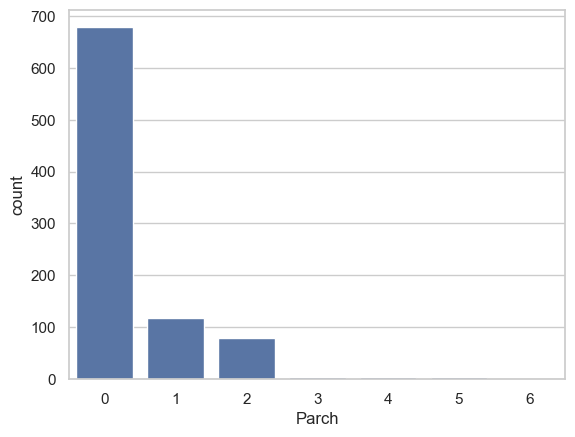

In [36]:
# Родители/Дети/Опекуны
sns.countplot(x='Parch', data=train)

## Предпроцессинг

In [3]:
# Меняем внутри Fare в Test и Train 0 на NaN
full_data = [train, test]

for data in full_data:
    data.loc[data['Fare'] == 0, 'Fare'] = np.nan

In [6]:
# Создаём новый признак title
for data in full_data:
    data['Title'] = data['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
train['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [14]:
# Заменяем мужские "титулы" на Mr, женские на Miss
for data in full_data:
    data['Title'] = data['Title'].replace(
        ['Mme', 'Ms', 'Lady', 'Mlle', 'the Countess', 'Dona'], 'Miss'
    )
    
    data['Title'] = data['Title'].replace(
        ['Major', 'Col', 'Capt', 'Don', 'Sir', 'Jonkheer'], 'Mr'
    )
    
    # Заменяем пол на числовой
    data['Sex'] = data['Sex'].replace(['male', 'female'], [1, 0]).astype(int)
train['Title'].value_counts()

Title
Mr        525
Miss      188
Mrs       125
Master     40
Dr          7
Rev         6
Name: count, dtype: int64

In [8]:
# Делаем несколько новых признаков
for data in full_data:
    data['Ticket_2letter'] = data.Ticket.apply(lambda x: x[:2])
    data['Ticket_len'] = data.Ticket.apply(lambda x: len(x))
    
    data['Cabin_num'] = data.Ticket.apply(lambda x: len(x.split()))
    data['Cabin_1letter'] = data.Ticket.apply(lambda x: x[:1])
    
    data['Fam_size'] = data['SibSp'] + data['Parch'] + 1
    
    #Делаем ещё доп. признак Тип семьи в зависимости от кол-ва членов семьи
    data['Fam_type'] = pd.cut(data.Fam_size, [0,1,4,7,11], labels=['Solo', 'Small', 'Big', 'Very big'])
    

## Работа с моделью

In [62]:
# В y мы добавляем наши ответы, в x данные для обучения
y = train['Survived']
features = ['Pclass', 'Fare', 'Title', 'Embarked', 'Fam_type', 'Ticket_len', 'Ticket_2letter']
X = train[features]

In [63]:
# Определяем числовые и категориальные колонки
numerical_cols = ['Fare']
categorical_cols = ['Pclass', 'Title', 'Embarked', 'Fam_type', 'Ticket_len', 'Ticket_2letter']
        
# Трансформер для числовых данных
numerical_transformer = SimpleImputer(strategy='median')
       
# Трансформер для категориальных данных
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
      
# Объединяем трансформеры через ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
       
# Строим полный пайплайн модели
titanic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=0, n_estimators=500, max_depth=5))
])


#Обучение модели
titanic_pipeline.fit(X,y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Title',
                                                   'Embarked', 'Fam_type',
                                                   'Ticket_len',
                                                   'Ticket_2letter'])])),
                ('model',
                 RandomForestClassifier(max_depth=5, n_estimators=500,
                                        random_state=0))])

In [64]:
# Получаем predictions
X_test = test[features]
predictions = titanic_pipeline.predict(X_test)

In [60]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predictions
})
submission.to_csv("submission_rf.csv", index=False)
print("Submission готов! Файл: submission_rf.csv")

Submission готов! Файл: submission_rf.csv
